# Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from eharmony import plotting
from eharmony.circular_harmonics import CircularHarmonics


In [3]:
L = 3
ch = CircularHarmonics(L)

# Plotting the Circular Harmonics

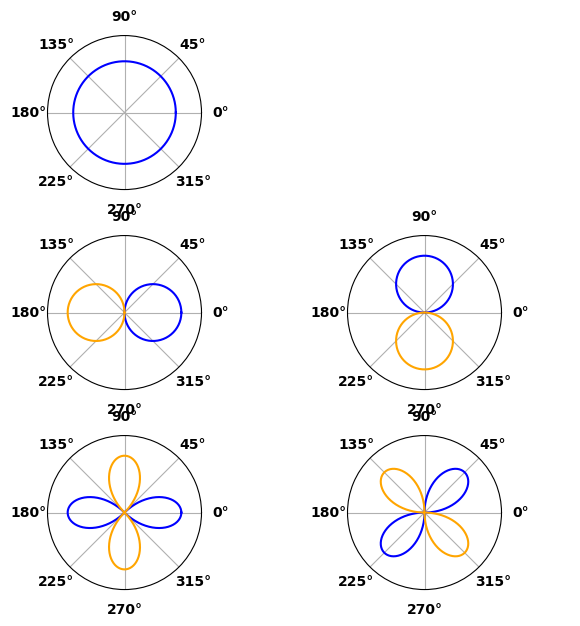

In [ ]:
fig = plt.figure(figsize=(6, L * 2))
subfigs = fig.subfigures(L, 2)

for l in range(L):
    for i in range(2):
        # L=0 is a scalar
        if l == 0 and i == 1:
            continue
        # L>0 has a cos and sin component
        ax = subfigs[l, i].add_subplot(projection="polar")
        lmax_index = max(0, 2 * l - 1)
        plotting.plot_circular_fn(
            ch.basis_fns[lmax_index + i].numpy(), ax=ax, plot_neg=True
        )

# Circular Harmonics Transform

In [6]:
import torch
from torch import nn

In [7]:
x = torch.linspace(0,2*np.pi, 360)
#y = torch.cos(x) + 2 * torch.sin(x) + torch.cos(10*x)
y = torch.ones_like(x) * 0.323
y[:40] = 0
y[210:] = 0

<PolarAxes: >

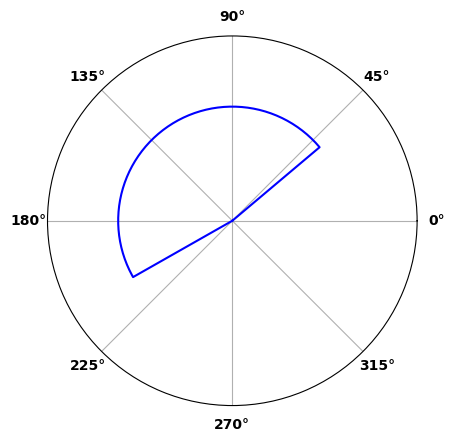

In [8]:
plotting.plot_circular_fn(y.numpy())

In [9]:
class CHT(nn.Module):
    def __init__(self, L=3, num_phi=360):
        super().__init__()
        self.w_lin = nn.Linear(num_phi, L*2-1)
        self.ch = CircularHarmonics(L)

    def forward(self, x):
        w = self.w_lin(x)
        return self.ch(w), w.detach()

In [10]:
ch_model = CHT(L)
optimizer = torch.optim.Adam(ch_model.parameters(), lr = 1e-3)

for iter in range(100):
    y_pred, _ = ch_model(y.view(1,-1))
    loss = (y_pred - y).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 10 == 0:
        print(f'iteration: {iter} loss: {loss.item()}')

iteration: 0 loss: 0.09213967621326447
iteration: 10 loss: 0.009359078481793404
iteration: 20 loss: 0.009520321153104305
iteration: 30 loss: 0.005706473253667355
iteration: 40 loss: 0.0055309259332716465
iteration: 50 loss: 0.004877162165939808
iteration: 60 loss: 0.004939217586070299
iteration: 70 loss: 0.0048706685192883015
iteration: 80 loss: 0.004866548348218203
iteration: 90 loss: 0.004861996043473482


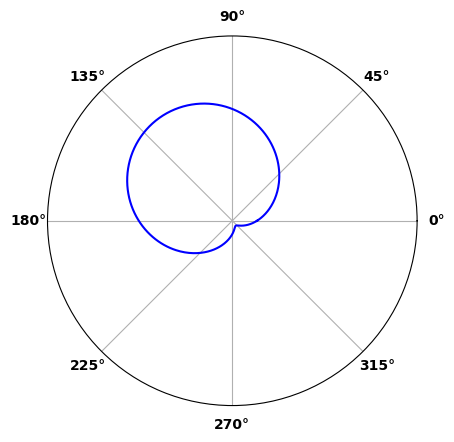

In [11]:
with torch.no_grad():
    pred, w = ch_model(y.view(1,-1))
    plotting.plot_circular_fn(pred.squeeze().numpy())

In [12]:
w_ch = ch_model.ch.basis_fns * w.T
print(w)

tensor([[ 0.3826, -0.2078,  0.2972, -0.0104, -0.0297]])


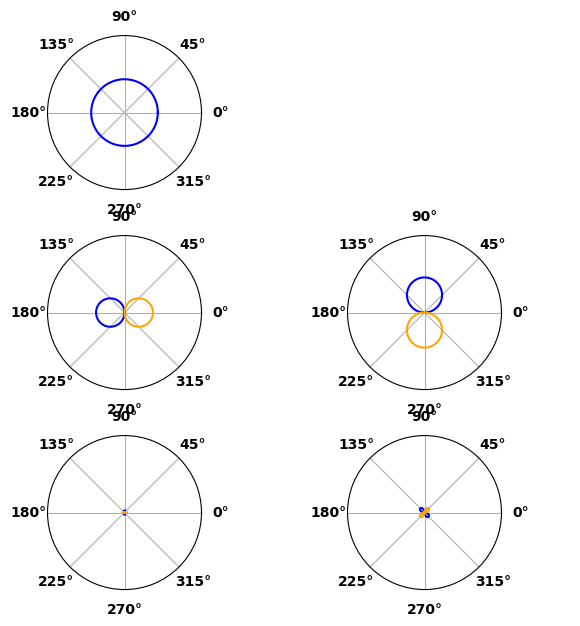

In [13]:
fig = plt.figure(figsize=(6,L*2))
subfigs = fig.subfigures(L, 2)

for l in range(L):
    for i in range(2):
        if l == 0 and i == 1:
            continue
        lmax_index = max(0, 2*l - 1)
        ax = subfigs[l,i].add_subplot(projection="polar")
        plotting.plot_circular_fn(w_ch[lmax_index+i].numpy(), ax=ax, plot_neg=True)